# Data Preparation

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.data_loader import load_all
from src.preprocessor import run_preprocessing_pipeline
from src.labeler import run_labeling
from src.config import FIGURES, DATA_PROC

sns.set_theme(style="whitegrid")

# Load Raw Data

In [2]:
df = load_all()
print(f"Data loaded: {df.shape[0]} tweets, {df.shape[1]} columns")
df[['source', 'provider', 'tweet_raw']].head(5)

[filter_cs_replies] Dropped 1 CS reply tweets by username
[filter_spam] Dropped 211 spam/foreign tweets
[drop_duplicates] Dropped 946 duplicate tweets
Data loaded: 4842 tweets, 5 columns


/home/muba/Work/Projects/sentimen-analisis-telekomunikasi-indonesia/notebooks/../src/data_loader.py:53: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask = df['tweet_raw'].str.contains(pattern, case=False, na=False, regex=True)


,source,provider,tweet_raw
0,playstore,telkomsel,halo Telkomsel kenapa kalau PLN mati jaringan ...
1,playstore,telkomsel,bagus
2,playstore,telkomsel,oi bisa ga si jaringan lu tiap malam ga ngeleg...
3,playstore,telkomsel,telkomsel skarang leletnya minta ampun. mw buk...
4,playstore,telkomsel,layanan dan promonya terbaik pertahankan min


# Text Preprocessing (Cleaning -> Stopwords -> Stemming)

In [3]:
df = run_preprocessing_pipeline(df)
print(f"Shape after preprocessing: {df.shape}")
df[['tweet_raw', 'tweet_processed']].head(5)

Preprocessing (Clean -> Stopwords -> Stemming):   0%|          | 0/4842 [00:00<?, ?it/s]

Preprocessing (Clean -> Stopwords -> Stemming):  15%|█▍        | 713/4842 [00:00<00:00, 7114.01it/s]

Preprocessing (Clean -> Stopwords -> Stemming):  34%|███▍      | 1656/4842 [00:00<00:00, 8473.33it/s]

Preprocessing (Clean -> Stopwords -> Stemming):  54%|█████▍    | 2619/4842 [00:00<00:00, 8997.02it/s]

Preprocessing (Clean -> Stopwords -> Stemming):  76%|███████▌  | 3677/4842 [00:00<00:00, 9619.37it/s]

Preprocessing (Clean -> Stopwords -> Stemming): 100%|██████████| 4842/4842 [00:00<00:00, 10085.98it/s]

[filter_empty] Dropped 56 tweets that became empty after preprocessing
Shape after preprocessing: (4786, 6)


,tweet_raw,tweet_processed
0,halo Telkomsel kenapa kalau PLN mati jaringan ...,halo telkomsel pln mati jaring telkomsel mati ...
1,bagus,bagus
2,oi bisa ga si jaringan lu tiap malam ga ngeleg...,oi si jaring malam lambat push renk anjing
3,telkomsel skarang leletnya minta ampun. mw buk...,telkomsel skarang lelet ampun buka aplikasi te...
4,layanan dan promonya terbaik pertahankan min,layan promonya baik tahan min


# Verifikasi Preprocessing

In [4]:
print("Perbandingan sebelum dan sesudah preprocessing:\n")
for i, row in df[['tweet_raw', 'tweet_processed']].head(5).iterrows():
    print(f"[RAW] {row['tweet_raw']}")
    print(f"[PROC] {row['tweet_processed']}")
    print("-" * 60)

Perbandingan sebelum dan sesudah preprocessing:

[RAW] halo Telkomsel kenapa kalau PLN mati jaringan Telkomsel juga mati? kendala nya apa ya? sudah sering sekali seperti itu, sementara provider lain kalau PLN mati jaringan nya tetap ada.
[PROC] halo telkomsel pln mati jaring telkomsel mati kendala provider pln mati jaring
------------------------------------------------------------
[RAW] bagus
[PROC] bagus
------------------------------------------------------------
[RAW] oi bisa ga si jaringan lu tiap malam ga ngeleg gw mau push renk ajgg
[PROC] oi si jaring malam lambat push renk anjing
------------------------------------------------------------
[RAW] telkomsel skarang leletnya minta ampun. mw buka aplikasi telkomsel sndri aja lama bngt apalgi mw hubungi cs telkomsel. sulit dan lelet bngt. terpaksa ku hapus aplikasi telkomsel berat bngt di gunnakan. loading trs
[PROC] telkomsel skarang lelet ampun buka aplikasi telkomsel apalgi hubung cs telkomsel sulit lelet paksa ku hapus aplikasi

# Auto-Labeling via Lexicon

In [5]:
df = run_labeling(df)
print(f"Data setelah labeling: {df.shape[0]} tweets")
df[['tweet_processed', 'pos_count', 'neg_count', 'label']].head(10)

Dropped 439 unlabelable rows (pos_count=0 and neg_count=0).
Data setelah labeling: 4347 tweets


,tweet_processed,pos_count,neg_count,label
0,halo telkomsel pln mati jaring telkomsel mati ...,3,4,0
1,bagus,1,0,1
2,oi si jaring malam lambat push renk anjing,1,3,0
3,telkomsel skarang lelet ampun buka aplikasi te...,0,7,0
4,layan promonya baik tahan min,1,0,1
5,kesini beli paket telkomsel mahal,1,1,0
6,daerah galaksi telkomsel jelek sinyal maki bag...,2,2,0
7,hadiah,1,0,1
8,jaring stabil minggu kemarin mahal jaring bagu...,7,4,1
9,aplikasi error notif tau tau kuota abis,0,5,0


# Distribusi Label Sentimen

/tmp/ipykernel_13904/2867585639.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=label_df, x='Label', y='Count', palette='RdYlGn', ax=axes[0])


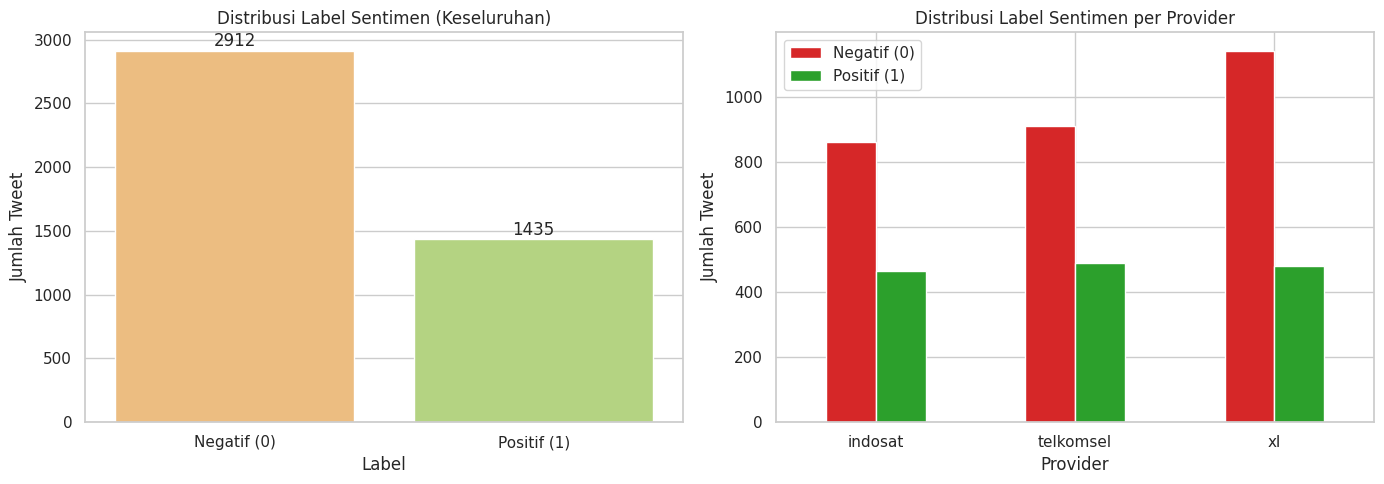


Tabel Distribusi Label per Provider:
           Negatif (0)  Positif (1)  Total  % Positif
provider                                             
indosat            860          466   1326      35.14
telkomsel          911          489   1400      34.93
xl                1141          480   1621      29.61
Total             2912         1435   4347      33.01


In [6]:
label_counts = df['label'].value_counts().sort_index()
label_names = ['Negatif (0)', 'Positif (1)']
label_df = pd.DataFrame({'Label': label_names, 'Count': [label_counts[0], label_counts[1]]})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=label_df, x='Label', y='Count', palette='RdYlGn', ax=axes[0])
axes[0].set_title('Distribusi Label Sentimen (Keseluruhan)')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Jumlah Tweet')
for i, v in enumerate(label_df['Count']):
    axes[0].text(i, v + 5, str(v), ha='center', va='bottom')

provider_label = df.groupby(['provider', 'label']).size().unstack(fill_value=0)
provider_label.plot(kind='bar', ax=axes[1], color=['#d62728', '#2ca02c'])
axes[1].set_title('Distribusi Label Sentimen per Provider')
axes[1].set_xlabel('Provider')
axes[1].set_ylabel('Jumlah Tweet')
axes[1].legend(['Negatif (0)', 'Positif (1)'])
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig(FIGURES / "02_distribusi_label.png")
plt.show()

print("\nTabel Distribusi Label per Provider:")
table = df.groupby(['provider', 'label']).size().unstack(fill_value=0)
table.columns = ['Negatif (0)', 'Positif (1)']
table['Total'] = table.sum(axis=1)
table.loc['Total'] = table.sum()
table['% Positif'] = (table['Positif (1)'] / table['Total'] * 100).round(2)
print(table)

# Save Processed Data

In [7]:
cols = ['source', 'provider', 'tweet_raw', 'tweet_processed', 'pos_count', 'neg_count', 'label']

DATA_PROC.mkdir(parents=True, exist_ok=True)

df[cols].to_csv(DATA_PROC / 'data_labeled.csv', index=False)
df[cols].to_csv(DATA_PROC / 'data_final.csv', index=False)

print(f"Data berhasil disimpan:")
print(f"  - {DATA_PROC / 'data_labeled.csv'}")
print(f"  - {DATA_PROC / 'data_final.csv'}")
print(f"  Total baris tersimpan: {len(df)}")

Data berhasil disimpan:
  - /home/muba/Work/Projects/sentimen-analisis-telekomunikasi-indonesia/data/processed/data_labeled.csv
  - /home/muba/Work/Projects/sentimen-analisis-telekomunikasi-indonesia/data/processed/data_final.csv
  Total baris tersimpan: 4347
